<a href="https://colab.research.google.com/github/Saksham-Official2601/Loan-Approval-Prediction-ML/blob/main/Saksham_Loan_Approval_Prediction_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Importing the Libraries

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

Loading the Data

In [25]:
train_df = pd.read_csv('train_u6lujuX_CVtuZ9i.csv')
test_df = pd.read_csv('test_Y3wMUE5_7gLdaTN.csv')

Inspect The Data

In [4]:
print("Train Data Info:")
print(train_df.info())
print("\nFirst 5 rows of Train Data:")
print(train_df.head())

Train Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB
None

First 5 rows of Train Data:
    Loan_ID Gender Married Dependents     Education Self_Empl

Check for missing values

In [5]:
print("\nMissing Values in Train Data:")
print(train_df.isnull().sum())


Missing Values in Train Data:
Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64


In [6]:
print("\nMissing Values in Test Data:")
print(test_df.isnull().sum())


Missing Values in Test Data:
Loan_ID               0
Gender               11
Married               0
Dependents           10
Education             0
Self_Employed        23
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount            5
Loan_Amount_Term      6
Credit_History       29
Property_Area         0
dtype: int64


In [8]:
# Copying to avoid warnings
train = train_df.copy()
test = test_df.copy()

Handling Missing Values

In [9]:
# Categorical columns
cat_cols = ['Gender', 'Married', 'Dependents', 'Self_Employed', 'Credit_History', 'Loan_Amount_Term']
for col in cat_cols:
    train[col] = train[col].fillna(train[col].mode()[0])
    test[col] = test[col].fillna(test[col].mode()[0])

In [10]:
# Numerical columns
train['LoanAmount'] = train['LoanAmount'].fillna(train['LoanAmount'].median())
test['LoanAmount'] = test['LoanAmount'].fillna(test['LoanAmount'].median())

Feature Engineering

In [11]:
train['Total_Income'] = train['ApplicantIncome'] + train['CoapplicantIncome']
test['Total_Income'] = test['ApplicantIncome'] + test['CoapplicantIncome']

In [12]:
# Log transformations to reduce skewness
train['LoanAmount_log'] = np.log(train['LoanAmount'])
test['LoanAmount_log'] = np.log(test['LoanAmount'])
train['Total_Income_log'] = np.log(train['Total_Income'])
test['Total_Income_log'] = np.log(test['Total_Income'])

In [14]:
# Encoding and Dropping Unnecessary Columns
cols_to_drop = ['Loan_ID', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Total_Income']
train_processed = train.drop(columns=cols_to_drop)
test_processed = test.drop(columns=cols_to_drop)

In [17]:
# Label Encoding for categorical variables
le = LabelEncoder()
encode_cols = ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area']

for col in encode_cols:
    train_processed[col] = le.fit_transform(train_processed[col])
    test_processed[col] = le.transform(test_processed[col])

# Encode Target
train_processed['Loan_Status'] = le.fit_transform(train_processed['Loan_Status']) # Y=1, N=0

Model Training

In [18]:
X = train_processed.drop('Loan_Status', axis=1)
y = train_processed['Loan_Status']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

Evaluation

In [19]:
y_pred = model.predict(X_val)
accuracy = accuracy_score(y_val, y_pred)
report = classification_report(y_val, y_pred)

print(f"Validation Accuracy: {accuracy:.4f}")
print("\nClassification Report:\n", report)

Validation Accuracy: 0.7642

Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.42      0.55        43
           1       0.75      0.95      0.84        80

    accuracy                           0.76       123
   macro avg       0.79      0.68      0.70       123
weighted avg       0.78      0.76      0.74       123



In [20]:
# Prediction on Test Set
test_predictions = model.predict(test_processed)
test_df['Loan_Status_Predicted'] = le.inverse_transform(test_predictions)

In [21]:
# Save processed train and predictions
train_processed.to_csv('cleaned_train_data.csv', index=False)
test_df.to_csv('loan_predictions_result.csv', index=False)

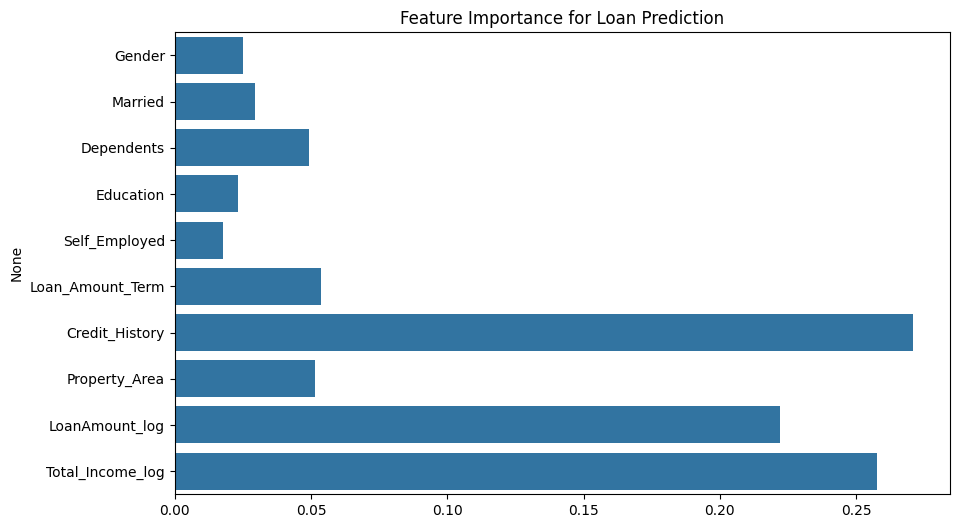

In [22]:
# Visualize Feature Importance
plt.figure(figsize=(10, 6))
sns.barplot(x=model.feature_importances_, y=X.columns)
plt.title('Feature Importance for Loan Prediction')
plt.savefig('feature_importance.png')

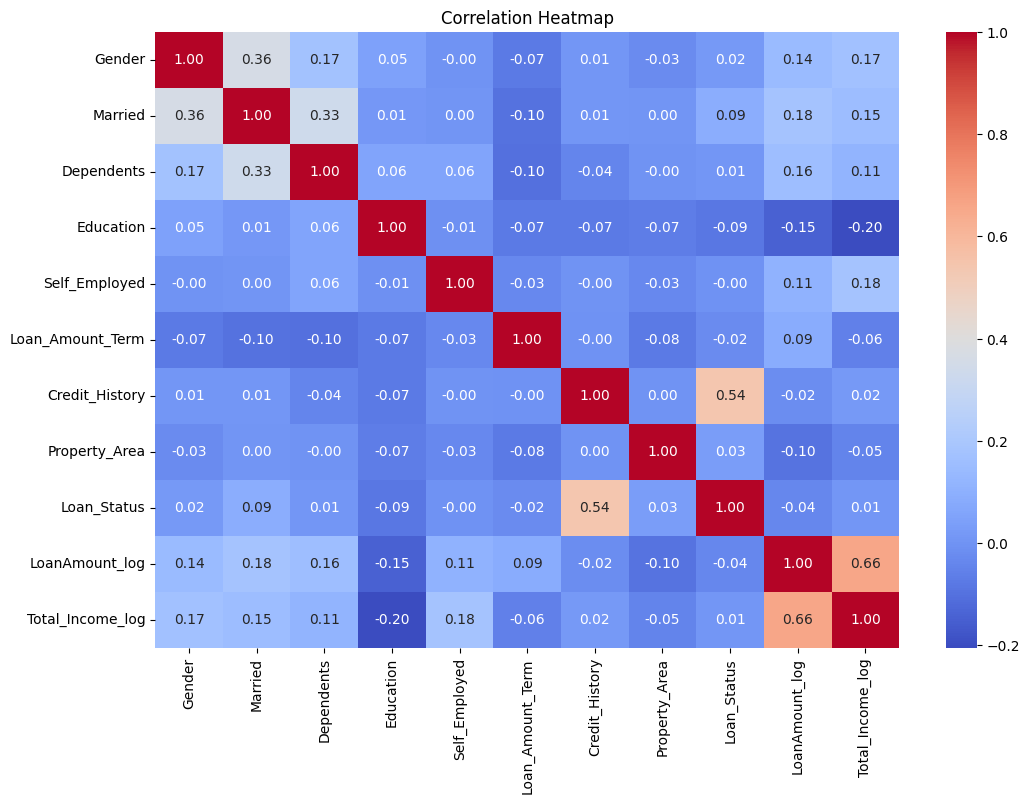

In [23]:
# Visualize Correlation Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(train_processed.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.savefig('correlation_heatmap.png')

In [24]:
from google.colab import files

files.download('cleaned_train_data.csv')
files.download('loan_predictions_result.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>